In [8]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator

In [9]:
## kml to struct
from xml.etree import ElementTree as ET

def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [10]:
# Load the KML file to get the polygon boundary
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

In [13]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})

mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)
expanded_mask = np.tile(mask_nan[np.newaxis, :, :], (432, 1, 1))

In [14]:
LON, LAT = np.meshgrid(ds.lon_rho.compute().values[0,:],ds.lat_rho.compute().values[:,0])
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

In [15]:
sphyto = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc',
                            chunks = {'time':1}).SPHYTO.isel(s_rho=-1)
lphyto = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc',
                            chunks = {'time':1}).LPHYTO.isel(s_rho=-1)

sphyto

<xarray.DataArray 'SPHYTO' (time: 1, eta_rho: 542, xi_rho: 602)> Size: 1MB
dask.array<getitem, shape=(1, 542, 602), dtype=float32, chunksize=(1, 542, 602), chunktype=numpy.ndarray>
Coordinates:
  * xi_rho   (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * eta_rho  (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 539.0 540.0 541.0 542.0
    s_rho    float64 8B -0.01562
    lon_rho  (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lat_rho  (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
  * time     (time) float32 4B 1.339e+06
Attributes:
    long_name:  averaged Small Phytoplankton
    units:      mmol N m-3
    field:      Small Phytoplankton, scalar, series

In [16]:
theta_m  =0.020;
coef =1.59
CN_Phyt  = 6.625;
chla=theta_m*(sphyto+lphyto)*CN_Phyt*12.;
chla.where(chla<=0,np.nan)
chla=coef*mask_nan*chla

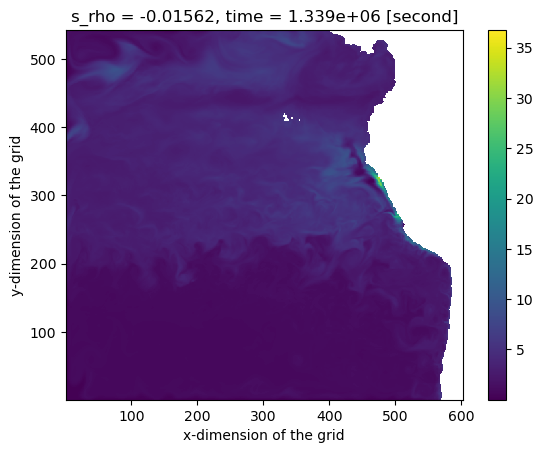

In [17]:
chla.plot()

In [18]:
# Lista ordenada de archivos
from pathlib import Path
files = sorted(Path("../../NHCS/hincast_1980-2015/").glob("croco_avg_Y*M*.nc"))

# Extraer tiempo desde nombre de archivo
def extract_datetime_from_filename(path):
    match = re.search(r"Y(\d{4})M(\d{2})", path.name)
    if match:
        year = int(match.group(1))
        month = int(match.group(2))
        return np.datetime64(f"{year}-{month:02d}")
    else:
        raise ValueError(f"Fecha no encontrada en nombre: {path.name}")

# Lista de tiempos correctos
time_values = [extract_datetime_from_filename(f) for f in files]

# Cargar variables LPHYTO y SPHYTO en superficie
def load_surface_phyto(path, time_val):
    time_val = np.datetime64(time_val, 'ns') 
    ds = xr.open_dataset(path, chunks={"time": 1})
    LPHYTO = ds["LPHYTO"].isel(s_rho=-1).squeeze("time", drop=True)
    SPHYTO = ds["SPHYTO"].isel(s_rho=-1).squeeze("time", drop=True)
    
    # Construir Dataset con ambas
    return xr.Dataset(
        {
            "LPHYTO": LPHYTO,
            "SPHYTO": SPHYTO
        },
        coords={"time": [time_val]}
    )

# Crear lista de Datasets
phyto_list = [load_surface_phyto(f, t) for f, t in zip(files, time_values)]

# Concatenar por tiempo
phyto_all = xr.concat(phyto_list, dim="time")


In [19]:
phyto_all

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, eta_rho: 542, xi_rho: 602)
Coordinates:
  * xi_rho   (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * eta_rho  (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 539.0 540.0 541.0 542.0
    s_rho    float64 8B -0.01562
    lon_rho  (eta_rho, xi_rho) float64 3MB -119.0 -118.9 ... -68.95 -68.87
    lat_rho  (eta_rho, xi_rho) float64 3MB -33.0 -33.0 -33.0 ... 10.03 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
Data variables:
    LPHYTO   (time, eta_rho, xi_rho) float32 564MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    SPHYTO   (time, eta_rho, xi_rho) float32 564MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>

In [20]:
theta_m  =0.020;
coef =1.59
CN_Phyt  = 6.625;
chla=theta_m*(phyto_all.SPHYTO+phyto_all.LPHYTO)*CN_Phyt*12.;
chla.where(chla<=0,np.nan)
chla=coef*mask_nan*chla
chla

<xarray.DataArray (time: 432, eta_rho: 542, xi_rho: 602)> Size: 1GB
dask.array<multiply, shape=(432, 542, 602), dtype=float64, chunksize=(1, 542, 602), chunktype=numpy.ndarray>
Coordinates:
  * xi_rho   (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * eta_rho  (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 539.0 540.0 541.0 542.0
    s_rho    float64 8B -0.01562
    lon_rho  (eta_rho, xi_rho) float64 3MB -119.0 -118.9 ... -68.95 -68.87
    lat_rho  (eta_rho, xi_rho) float64 3MB -33.0 -33.0 -33.0 ... 10.03 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01

In [23]:
# chla = chla.rename({'lon_rho':'lon','lat_rho':'lat'})

CHLA = xr.Dataset(
    data_vars={
        'chla': (("time", "lat","lon"), chla.data * expanded_mask *inshore_mask),
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':chla.time
}
)

CHLA

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
    s_rho    float64 8B -0.01562
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
Data variables:
    chla     (time, lat, lon) float64 1GB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>

In [42]:
# CHLA.to_netcdf('../../NHCS/hincast_1980-2015/Chlorophyll')

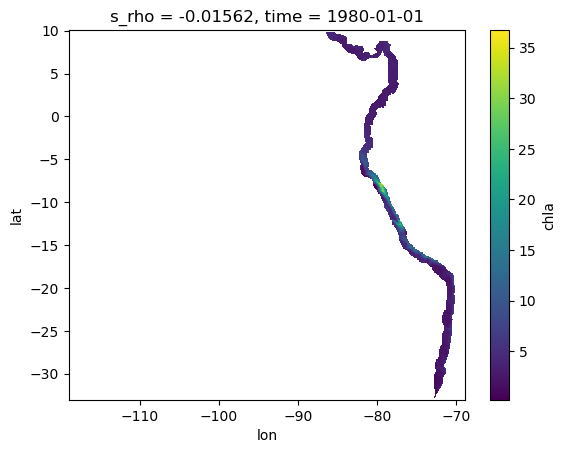

In [24]:
CHLA.chla.isel(time=0).plot()

In [25]:
def seasonality(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

In [32]:
chl_season = seasonality(CHLA)
chl_season = chl_season.compute()

Text(0.5, 1.0, 'Chlor')

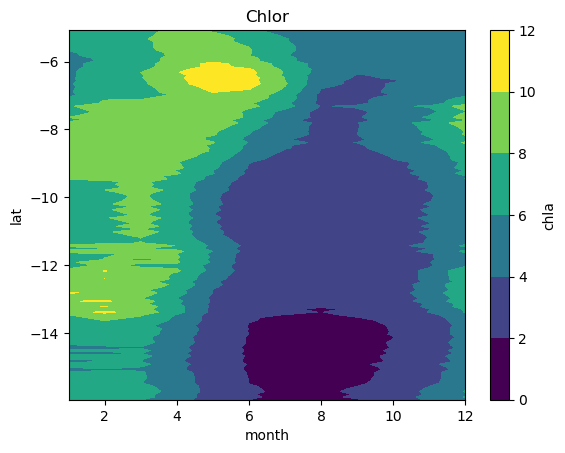

In [36]:
chl_season.chla.sel(lat=slice(-16,-5)).mean(dim='lon',skipna=True).plot.contourf(x='month',y='lat')
plt.title('Chlor')

In [40]:
CHLA_ = CHLA.chla.sel(lat=slice(-16,-5)).mean(dim=('lon','lat'),skipna=True).compute()

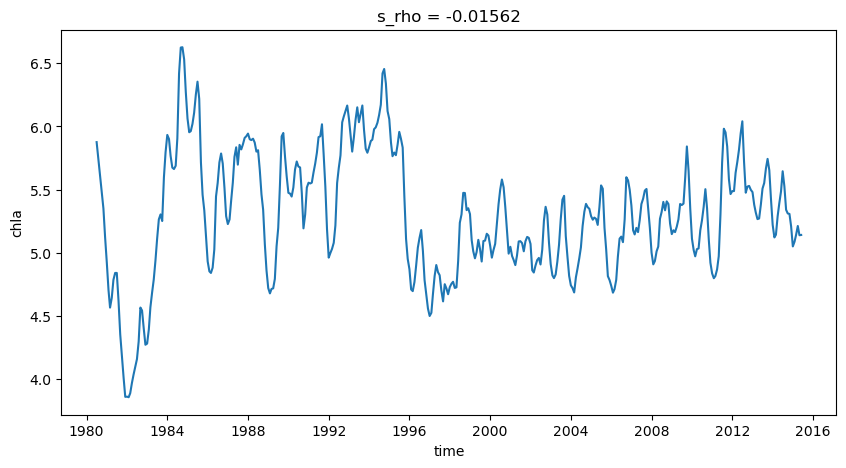

In [41]:
CHLA_.rolling(time=13,center=True).mean().plot(figsize=(10,5))

### Loading Upwelling Indices

In [43]:
## generate time
time = pd.date_range(start='1980-01', end='2016-01', freq='M')
##------CUI_model
CUI = loadmat("../../NHCS/Processed/CUI_SST_index.mat")
CUI_cc = np.array(CUI['CUI_SSTi']).squeeze()
lati_cc = np.array(CUI['lati']).squeeze()
##----Ekman 
Ekman_data = loadmat("../../NHCS/Processed/EKMAN_components.mat")
Ek_pump = Ekman_data['EK_pump']
# ## Ekman transport
Ek_tr = Ekman_data['UEK']*-1

#----- Analytical Velocity
AV_data = loadmat("../../NHCS/Processed/AV.mat")
Coastal_up = loadmat("../../NHCS/Processed/Coastal_upwelling.mat")

#----- CUTI
CUTI_data = loadmat("../../NHCS/Processed/CUTI.mat")

#-------- BEUTI
BEUTI_data = loadmat("../../NHCS/Processed/BEUTI.mat")

#-------- BUI 
BUI_data = loadmat("../../NHCS/Processed/BUI.mat")

#----- CROCO wmld
WMLD_data = loadmat("../../NHCS/Processed/WMLD_MLD.mat")

CUI_ds = xr.DataArray(
    data=CUI_cc.T,  # numpy array of Mean_CUI
    dims=["time",'lat'],  # Dimension matches the time in CUI_MAX
    coords={"time": time,
           'lat': lati_cc},  # Ensure matching time coordinates
    name="CUI_cc"  # Name for the variable
)

/tmp/ipykernel_616844/2426928416.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time = pd.date_range(start='1980-01', end='2016-01', freq='M')


In [44]:
UI_ds = xr.Dataset(
    data_vars={
        'WMLD': (("time", "lat","lon"), WMLD_data['WMLD'].transpose(2, 0, 1)),
        'Ekman_pump': (("time", "lat","lon"), Ek_pump.transpose(2, 1, 0)),
        'Ekman_transport':(("time", "lat","lon"), Ek_tr.transpose(2, 1, 0)),
        'AV': (("time", "lat","lon"), AV_data['W_analytical'].transpose(2, 1, 0)),
        # 'CUpwelling':(('time','lat','lon'),Coastal_up['WcMean'].transpose(2, 1, 0)),
        # 'HUI': (("time", "lat","lon"), HUI_data['HUI'].transpose(2, 1, 0)),
        'CUTI': (("time", "lat","lon"), CUTI_data['CUTI'].transpose(2, 1, 0) *-1),
        'BEUTI': (("time", "lat","lon"), BEUTI_data['BEUTI'].transpose(2, 1, 0) *-1),
        'BUI': (("time", "lat","lon"), BUI_data['BUI'].transpose(2, 1, 0)),        
    },
    coords = {
        'lon':ds.lon_rho.compute().values[0,:],
        'lat':ds.lat_rho.compute().values[:,0],
        'time':time
}
)

mask_rho = ds.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)

UI_ds = UI_ds * inshore_mask *mask_nan

In [46]:
UI_season = seasonality(UI_ds)
UI_season

<xarray.Dataset> Size: 219MB
Dimensions:          (month: 12, lat: 542, lon: 602)
Coordinates:
  * lon              (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat              (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.869 9.951 10.03
  * month            (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    WMLD             (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    Ekman_pump       (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    Ekman_transport  (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    AV               (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    CUTI             (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    BEUTI            (month, lat, lon) float64 31MB nan nan nan ... nan nan nan
    BUI              (month, lat, lon) float64 31MB nan nan nan ... nan nan nan

In [57]:
def normalize(data):
    return (data - data.min()) / (data.max() - data.min())

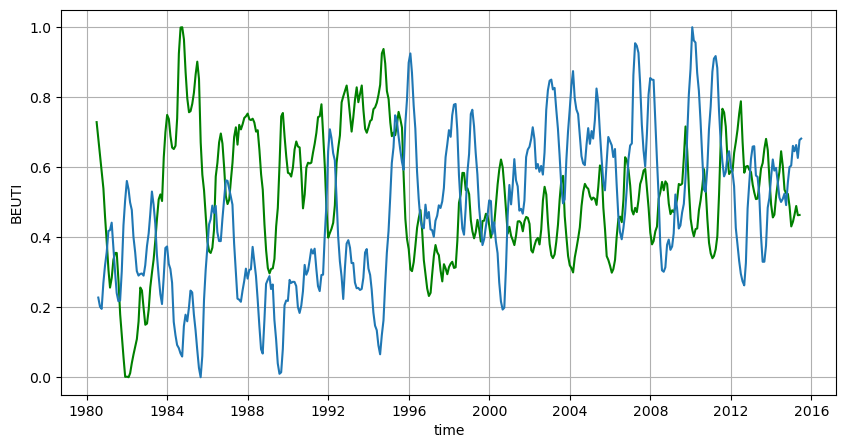

In [60]:
normalize(CHLA_.rolling(time=13,center=True).mean()).plot(figsize=(10,5),color='green')
normalize(UI_ds.BEUTI.sel(lat=slice(-16,-5)).mean(dim=('lon','lat')).rolling(time=13,center=True).mean()).plot()
plt.grid()

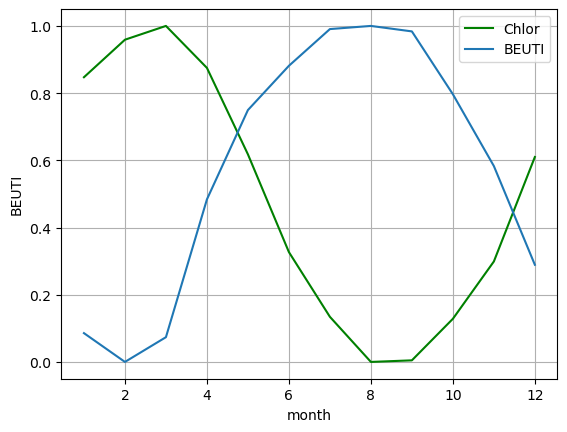

In [84]:
normalize(chl_season.chla.sel(lat=slice(-16,-5)).mean(dim=('lon','lat'),skipna=True)).plot(label='Chlor',color='green')

normalize(seasonality(UI_ds.BEUTI.sel(lat=slice(-16,-5))).mean(dim=('lon','lat'))).plot(label='BEUTI')
plt.grid()
plt.legend()

In [87]:
# Suavizados temporales
CHLA_smoothed = CHLA_.rolling(time=13, center=True).mean()
CHLA_smoothed = CHLA_smoothed.drop_vars("s_rho", errors="ignore")

BEUTI_smoothed = UI_ds.BEUTI.sel(lat=slice(-16, -5)).mean(dim=('lon', 'lat')).rolling(time=13, center=True).mean()

In [113]:
import pandas as pd

chla_series = CHLA_smoothed.to_series()
beuti_series = BEUTI_smoothed.to_series()

df = pd.concat([chla_series, beuti_series], axis=1)
df.columns = ['CHLA', 'BEUTI']

# df_clean = df.dropna()

# correlation = df_clean.corr().loc['CHLA', 'BEUTI']
# print("Correlation =", correlation)


In [118]:
df1 =  pd.DataFrame(
    {
        "CHLA":CHLA_smoothed.data,
        "BEUTI":BEUTI_smoothed.data
    }
)
df1.corr()

,CHLA,BEUTI
CHLA,1.000000,-0.423403
BEUTI,-0.423403,1.000000
